In [1]:
# 세팅
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# 파일 선택
my_filepath = "/kaggle/input/datasets/paresh2047/uci-semcom/uci-secom.csv"
my_data = pd.read_csv(my_filepath)

/tmp/ipykernel_17/4053111649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=null_top50.index, y=null_top50.values, palette='viridis')


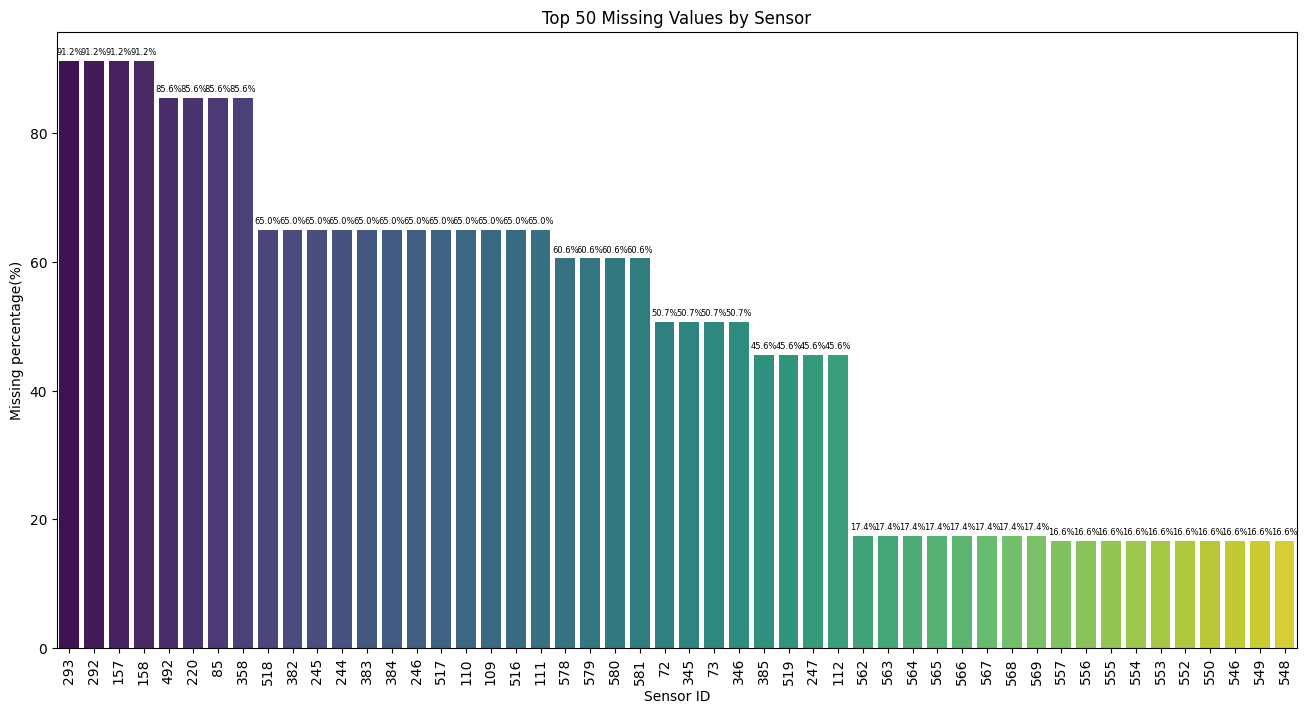

In [3]:
# 그래프 그리기(결측치 비율 top50 columns를 bar plot으로 시각화)

# secom dataset의 결측치의 비율을 "null_counts" Series로 저장
null_percent = my_data.isnull().mean()*100
# 상위 50개의 데이터만 추출
null_top50 = null_percent.sort_values(ascending=False).head(50)

plt.figure(figsize=(16,8))

# 막대그래프 작성
ax = sns.barplot(x=null_top50.index, y=null_top50.values, palette='viridis')

# 각 막대의 위에 값 레이블 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=6)
"""
ax.containers: 막대그래프 지칭
fmt='%.1f%%': "%.1f"(소수점 첫째까지 표시), "%%"(뒤에 % 붙임)
padding: 그래프와 간격 띄우기
"""

plt.title("Top 50 Missing Values by Sensor")
plt.xlabel("Sensor ID")
plt.ylabel("Missing percentage(%)")
# x축 눈금의 값을 반시계 방향으로 90도 회전
plt.xticks(rotation=90)

plt.show()

In [4]:
# constant columns 제거
n_unique = my_data.nunique()
constant_cols = n_unique[n_unique <= 1].index

print(f"상수 열의 개수: {len(constant_cols)}")
print(f"상수 열 목록: {constant_cols.tolist()}")
""".tolist(): 판다스나 넘파이의 인덱스나 시리즈 객체를 파이썬 기본 리스트 형태로 변환
"""

my_data_dropped1 = my_data.drop(columns=constant_cols)

print(f"제거된 상수 열 개수: {len(constant_cols)}")
print(f"원본 열 개수: {my_data.shape[1]}")
print(f"제거 후 열 개수: {my_data_dropped1.shape[1]}")
""".shape[?}: 0 -> 행이 개수, 1 -> 열의 개수
"""

# 결측치 45.6% 이상 columns 제거
cols_to_drop = null_percent[null_percent >= 45.6].index

print(f"결측치 45.6% 이상 열 개수: {len(cols_to_drop)}")

my_data_dropped2 = my_data_dropped1.drop(columns=cols_to_drop)

print(f"원본 열 개수: {my_data.shape[1]}")
print(f"최종 열 개수: {my_data_dropped2.shape[1]}")

상수 열의 개수: 116
상수 열 목록: ['5', '13', '42', '49', '52', '69', '97', '141', '149', '178', '179', '186', '189', '190', '191', '192', '193', '194', '226', '229', '230', '231', '232', '233', '234', '235', '236', '237', '240', '241', '242', '243', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '276', '284', '313', '314', '315', '322', '325', '326', '327', '328', '329', '330', '364', '369', '370', '371', '372', '373', '374', '375', '378', '379', '380', '381', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '414', '422', '449', '450', '451', '458', '461', '462', '463', '464', '465', '466', '481', '498', '501', '502', '503', '504', '505', '506', '507', '508', '509', '512', '513', '514', '515', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538']
제거된 상수 열 개수: 116
원본 열 개수: 592
제거 후 열 개수: 476
결측치 45.6% 이상 열 개수: 32
원본 열 개수: 592
최종 열 개수: 444


In [5]:
# 나머지 결측치 중앙값으로 대체: 반도체 제조 공정의 센서 데이터를 고려할떄, 이상치와 평균의 함정의 리스크를 피하기 위해 중앙값으로 대체
final_data = my_data_dropped2.fillna(my_data_dropped2.median(numeric_only=True))
""".fillna(?): dataframe 내의 NaN으로 표시된 모든 칸을 ?로 대체함
   numeric_only=True: 숫자 데이터만 계산함 -> 문자 데이터 계산 시도로 인한 에러 방지
"""

print(f"결측치 수: {final_data.isnull().sum().sum()}")
final_data.head(10)

결측치 수: 0


,Time,0,1,2,3,4,6,7,8,9,...,577,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
5,2008-07-19 17:53:00,2946.25,2432.84,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5287,0.0167,...,13.7755,0.4949,0.0189,0.0044,3.8276,0.0342,0.0151,0.0052,44.0077,-1
6,2008-07-19 19:44:00,3030.27,2430.12,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.5816,-0.0270,...,8.3645,0.5010,0.0143,0.0042,2.8515,0.0342,0.0151,0.0052,44.0077,-1
7,2008-07-19 19:45:00,3058.88,2690.15,2248.9000,1004.4692,0.7884,106.2400,0.1185,1.5153,0.0157,...,16.0862,0.4984,0.0106,0.0034,2.1261,0.0204,0.0194,0.0063,95.0310,-1
8,2008-07-19 20:24:00,2967.68,2600.47,2248.9000,1004.4692,0.7884,106.2400,0.1185,1.5358,0.0111,...,14.2892,0.4993,0.0172,0.0046,3.4456,0.0111,0.0124,0.0045,111.6525,-1
9,2008-07-19 21:35:00,3016.11,2428.37,2248.9000,1004.4692,0.7884,106.2400,0.1185,1.5381,0.0159,...,7.4181,0.4967,0.0152,0.0038,3.0687,0.0212,0.0191,0.0073,90.2294,-1


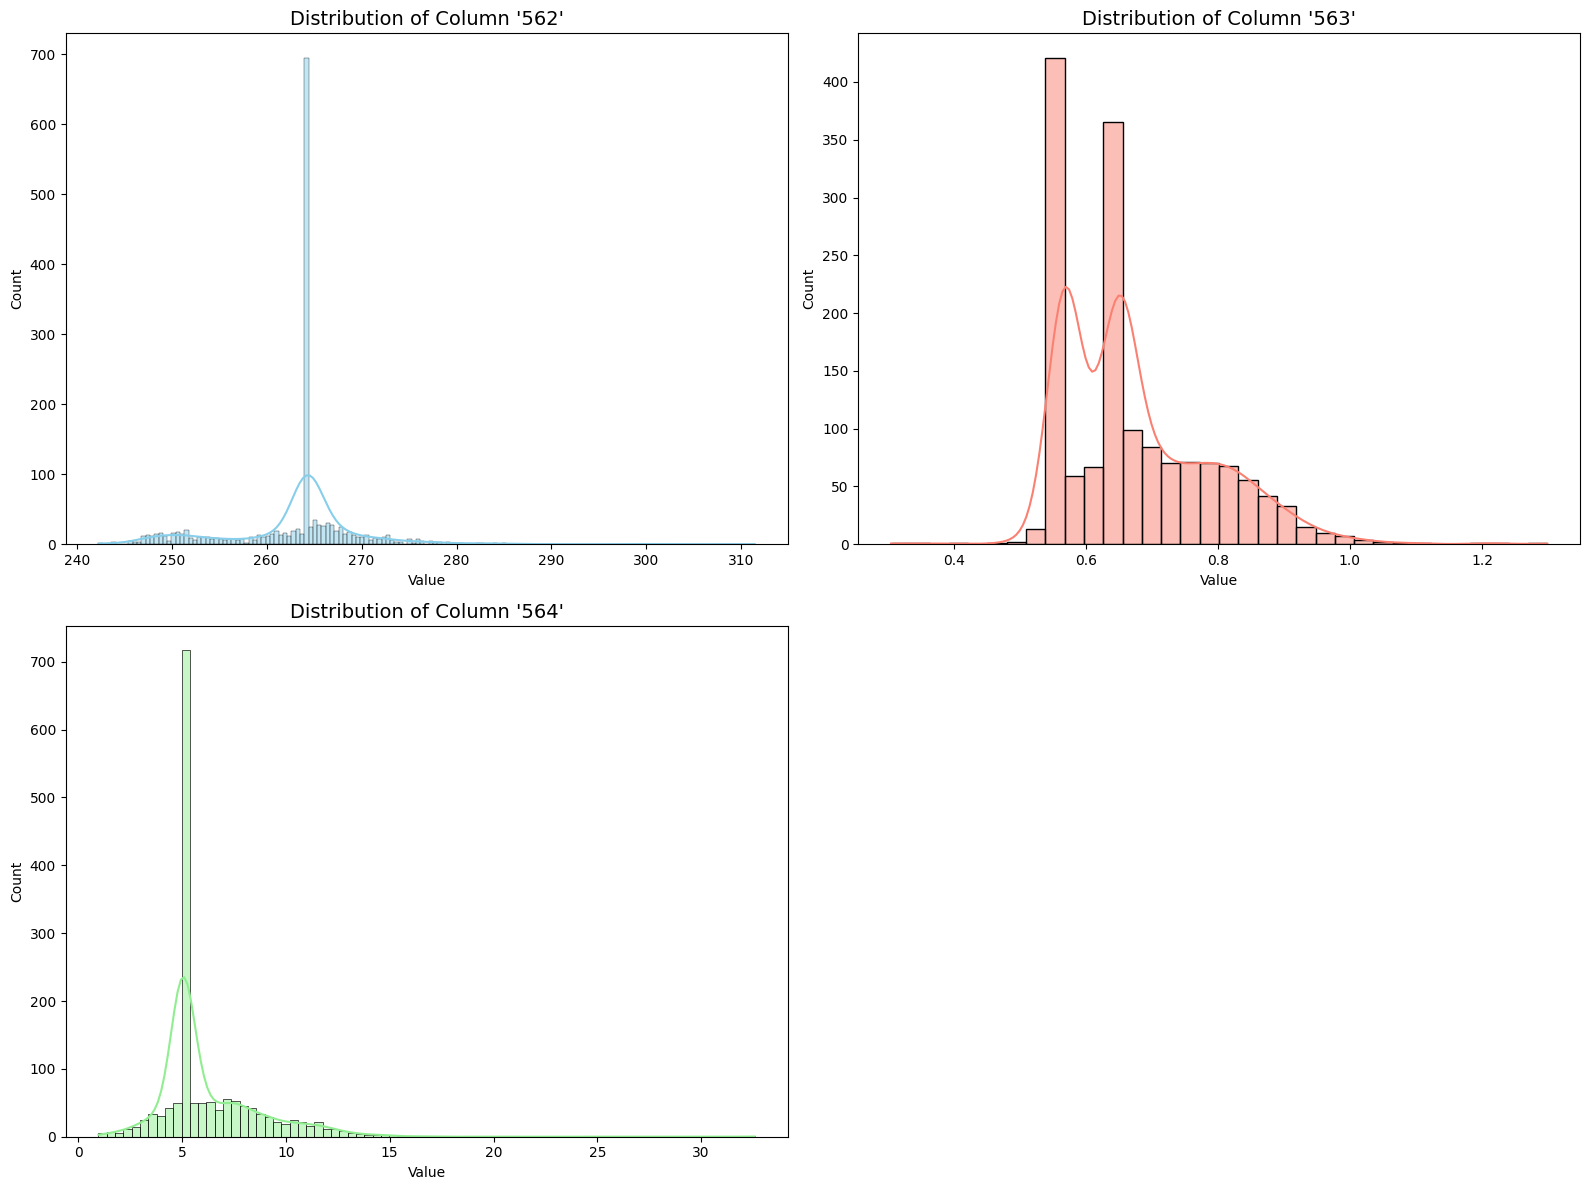

In [6]:
# final_data의 최대 결측치를 가졌던 column의 데이터 분포 조사
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
"""
fig: plot ouput 전체를 관리하는 객체
axes: 각각의 칸들을 답고 있는 리스트
plt.subplot(a, b): a -> 행 개수, b -> 열 개수  
"""
sns.histplot(final_data['562'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("Distribution of Column '562'", fontsize=14)
axes[0, 0].set_xlabel("Value")

sns.histplot(final_data['563'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title("Distribution of Column '563'", fontsize=14)
axes[0, 1].set_xlabel("Value")

sns.histplot(final_data['564'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title("Distribution of Column '564'", fontsize=14)
axes[1, 0].set_xlabel("Value")

# 마지막 칸[1,1] 숨기기
axes[1, 1].axis('off')

# 그래프 간 간격 자동 조절
plt.tight_layout()
plt.show()

In [7]:
print(final_data['562'].median())
print(final_data['563'].median())
print(final_data['564'].median())

264.272
0.651
5.16
